In [1]:
#Load dataset
import pandas as pd

from pathlib import Path

file_name = "hotel_booking_cancellation_dataset.xlsx"

data_path = Path(file_name)

print("Current dataset path:", data_path)

print("File exists:", data_path.exists())

df = pd.read_excel(data_path)

print("Dataset loaded successfully!")

df.head()

Current dataset path: hotel_booking_cancellation_dataset.xlsx
File exists: True
Dataset loaded successfully!


,Booking_ID,Customer_Age,Booking_Channel,Room_Type,Number_of_Nights,Number_of_Guests,Booking_Lead_Time_Days,Total_Booking_Value,Previous_Bookings,Special_Requests,Deposit_Paid,Loyalty_Member,Travel_Purpose,Booking_Cancelled
0,1,52.0,Website,Standard,10,5,175,3033.0,2,2,No,Yes,Event,No
1,2,18.0,Third-party Platform,Standard,10,4,66,410.0,7,2,Yes,No,Family,No
2,3,59.0,Website,Standard,4,1,177,2922.0,9,3,Yes,Yes,Leisure,No
3,4,75.0,Phone,Family,3,5,74,453.0,2,3,No,No,Business,No
4,5,77.0,Website,Standard,10,3,11,2782.0,6,4,Yes,No,Event,No


In [2]:
#Inspect dataset
print('The number of rows and columns: ')
df.shape

The number of rows and columns: 


(376, 14)

In [3]:
print('The names of all columns: ')
df.columns

The names of all columns: 


Index(['Booking_ID', 'Customer_Age', 'Booking_Channel', 'Room_Type',
       'Number_of_Nights', 'Number_of_Guests', 'Booking_Lead_Time_Days',
       'Total_Booking_Value', 'Previous_Bookings', 'Special_Requests',
       'Deposit_Paid', 'Loyalty_Member', 'Travel_Purpose',
       'Booking_Cancelled'],
      dtype='object')

In [4]:
print('General information about the dataset:')
df.info()

General information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Booking_ID              376 non-null    int64  
 1   Customer_Age            369 non-null    float64
 2   Booking_Channel         370 non-null    object 
 3   Room_Type               370 non-null    object 
 4   Number_of_Nights        376 non-null    int64  
 5   Number_of_Guests        376 non-null    int64  
 6   Booking_Lead_Time_Days  376 non-null    int64  
 7   Total_Booking_Value     369 non-null    float64
 8   Previous_Bookings       376 non-null    int64  
 9   Special_Requests        376 non-null    int64  
 10  Deposit_Paid            370 non-null    object 
 11  Loyalty_Member          376 non-null    object 
 12  Travel_Purpose          370 non-null    object 
 13  Booking_Cancelled       376 non-null    object 
dtypes: 

In [5]:
print('The data type of each column: ')
df.dtypes

The data type of each column: 


Booking_ID                  int64
Customer_Age              float64
Booking_Channel            object
Room_Type                  object
Number_of_Nights            int64
Number_of_Guests            int64
Booking_Lead_Time_Days      int64
Total_Booking_Value       float64
Previous_Bookings           int64
Special_Requests            int64
Deposit_Paid               object
Loyalty_Member             object
Travel_Purpose             object
Booking_Cancelled          object
dtype: object

In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Booking_ID                0
Customer_Age              7
Booking_Channel           6
Room_Type                 6
Number_of_Nights          0
Number_of_Guests          0
Booking_Lead_Time_Days    0
Total_Booking_Value       7
Previous_Bookings         0
Special_Requests          0
Deposit_Paid              6
Loyalty_Member            0
Travel_Purpose            6
Booking_Cancelled         0
dtype: int64


In [7]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
6


In [8]:
#Understand the business problem
business_problem = "A company wants to predict which customers are likely to cancel their booking."
ml_problem = "This is a classification problem because we want to predict whether the customer will cancel the booking or not."
prediction_goal = "Predict whether a customer will cancel the booking: Yes or No."

print("Business Problem:\n", business_problem)

print("\nMachine Learning Problem:\n", ml_problem)

print("\nPrediction Goal:\n", prediction_goal)

Business Problem:
 A company wants to predict which customers are likely to cancel their booking.

Machine Learning Problem:
 This is a classification problem because we want to predict whether the customer will cancel the booking or not.

Prediction Goal:
 Predict whether a customer will cancel the booking: Yes or No.


In [9]:
#Basic Data Cleaning: Duplicated and missing values
df_clean = df.copy()
print("Original dataset shape:")
print(df_clean.shape)

df_clean = df_clean.drop_duplicates()
print("Dataset shape after removing duplicate rows:")
print(df_clean.shape)
print("\nNumber of duplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Original dataset shape:
(376, 14)
Dataset shape after removing duplicate rows:
(370, 14)

Number of duplicate rows after cleaning:
0


In [10]:
numeric_columns = [
    "Customer_Age",
    "Number_of_Nights",
    "Number_of_Guests",
    "Booking_Lead_Time_Days",
    "Total_Booking_Value",
    "Previous_Bookings",
    "Special_Requests"
]

categorical_columns = [
    "Booking_Channel",
    "Room_Type",
    "Deposit_Paid",
    "Loyalty_Member",
    "Travel_Purpose"
]

In [11]:
for column in numeric_columns:
    median_value = df_clean[column].median()
    df_clean[column] = df_clean[column].fillna(median_value)

In [12]:
for column in categorical_columns:
    mode_value = df_clean[column].mode()[0]
    df_clean[column] = df_clean[column].fillna(mode_value)

In [13]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print("\nCleaned dataset preview:")
display(df_clean.head())

Missing values after cleaning:
Booking_ID                0
Customer_Age              0
Booking_Channel           0
Room_Type                 0
Number_of_Nights          0
Number_of_Guests          0
Booking_Lead_Time_Days    0
Total_Booking_Value       0
Previous_Bookings         0
Special_Requests          0
Deposit_Paid              0
Loyalty_Member            0
Travel_Purpose            0
Booking_Cancelled         0
dtype: int64

Cleaned dataset preview:


,Booking_ID,Customer_Age,Booking_Channel,Room_Type,Number_of_Nights,Number_of_Guests,Booking_Lead_Time_Days,Total_Booking_Value,Previous_Bookings,Special_Requests,Deposit_Paid,Loyalty_Member,Travel_Purpose,Booking_Cancelled
0,1,52.0,Website,Standard,10,5,175,3033.0,2,2,No,Yes,Event,No
1,2,18.0,Third-party Platform,Standard,10,4,66,410.0,7,2,Yes,No,Family,No
2,3,59.0,Website,Standard,4,1,177,2922.0,9,3,Yes,Yes,Leisure,No
3,4,75.0,Phone,Family,3,5,74,453.0,2,3,No,No,Business,No
4,5,77.0,Website,Standard,10,3,11,2782.0,6,4,Yes,No,Event,No


In [14]:
#Convert Customer Age to integer
df_clean["Customer_Age"] = df_clean["Customer_Age"].astype(int)
df_clean["Number_of_Nights"] = df_clean["Number_of_Nights"].astype(int)
df_clean["Number_of_Guests"] = df_clean["Number_of_Guests"].astype(int)
df_clean["Booking_Lead_Time_Days"] = df_clean["Booking_Lead_Time_Days"].astype(int)
df_clean["Total_Booking_Value"] = df_clean["Total_Booking_Value"].astype(float)
df_clean["Previous_Bookings"] = df_clean["Previous_Bookings"].astype(int)
df_clean["Special_Requests"] = df_clean["Special_Requests"].astype(int)

df_clean["Booking_Channel"] = df_clean["Booking_Channel"].astype("category")
df_clean["Room_Type"] = df_clean["Room_Type"].astype("category")
df_clean["Deposit_Paid"] = df_clean["Deposit_Paid"].astype("category")
df_clean["Loyalty_Member"] = df_clean["Loyalty_Member"].astype("category")
df_clean["Travel_Purpose"] = df_clean["Travel_Purpose"].astype("category")

print(df_clean.dtypes)

Booking_ID                   int64
Customer_Age                 int64
Booking_Channel           category
Room_Type                 category
Number_of_Nights             int64
Number_of_Guests             int64
Booking_Lead_Time_Days       int64
Total_Booking_Value        float64
Previous_Bookings            int64
Special_Requests             int64
Deposit_Paid              category
Loyalty_Member            category
Travel_Purpose            category
Booking_Cancelled           object
dtype: object


In [15]:
#Replace the original dataframe with the cleaned dataframe
df = df_clean.copy()

In [16]:
#Identify the features and target variable
feature_columns = [
    "Customer_Age",
    "Booking_Channel",
    "Room_Type",
    "Number_of_Nights",
    "Number_of_Guests",
    "Booking_Lead_Time_Days",
    "Total_Booking_Value",
    "Previous_Bookings",
    "Special_Requests",
    "Deposit_Paid",
    "Loyalty_Member",
    "Travel_Purpose"
]

target_column = "Booking_Cancelled"

#Define X and y
X = df[feature_columns]
y = df[target_column]

print("Feature Columns:\n")
display(X.head())
print("Shape of X:", X.shape)

print("\nTarget Column:\n")
display(y.head())
print("Shape of y:", y.shape)
print("\nTarget values:")
print(df[target_column].value_counts())

Feature Columns:



,Customer_Age,Booking_Channel,Room_Type,Number_of_Nights,Number_of_Guests,Booking_Lead_Time_Days,Total_Booking_Value,Previous_Bookings,Special_Requests,Deposit_Paid,Loyalty_Member,Travel_Purpose
0,52,Website,Standard,10,5,175,3033.0,2,2,No,Yes,Event
1,18,Third-party Platform,Standard,10,4,66,410.0,7,2,Yes,No,Family
2,59,Website,Standard,4,1,177,2922.0,9,3,Yes,Yes,Leisure
3,75,Phone,Family,3,5,74,453.0,2,3,No,No,Business
4,77,Website,Standard,10,3,11,2782.0,6,4,Yes,No,Event


Shape of X: (370, 12)

Target Column:



0    No
1    No
2    No
3    No
4    No
Name: Booking_Cancelled, dtype: object

Shape of y: (370,)

Target values:
No     345
Yes     25
Name: Booking_Cancelled, dtype: int64


In [17]:
y = y.map({"No": 0, "Yes": 1})
print("Target value counts after conversion:")
print(y.value_counts())

Target value counts after conversion:
0    345
1     25
Name: Booking_Cancelled, dtype: int64


In [18]:
#Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:")
print(X_train.shape)

print("X_test shape:")
print(X_test.shape)

print("y_train shape:")
print(y_train.shape)

print("y_test shape:")
print(y_test.shape)

X_train shape:
(296, 12)
X_test shape:
(74, 12)
y_train shape:
(296,)
y_test shape:
(74,)


In [19]:
#Apply preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_columns = [
    "Customer_Age",
    "Number_of_Nights",
    "Number_of_Guests",
    "Booking_Lead_Time_Days",
    "Total_Booking_Value",
    "Previous_Bookings",
    "Special_Requests"
]

categorical_columns = [
    "Booking_Channel",
    "Room_Type",
    "Deposit_Paid",
    "Loyalty_Member",
    "Travel_Purpose"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)


X_train_preprocessed = preprocessor.fit_transform(X_train)
print("X_train preprocessing completed!")

X_test_preprocessed = preprocessor.transform(X_test)
print("X_test preprocessing completed!")

print("Summary of preprocessing shapes:")
print("X_train before preprocessing:", X_train.shape)
print("X_train after preprocessing:", X_train_preprocessed.shape)
print("X_test before preprocessing:", X_test.shape)
print("X_test after preprocessing:", X_test_preprocessed.shape)

X_train preprocessing completed!
X_test preprocessing completed!
Summary of preprocessing shapes:
X_train before preprocessing: (296, 12)
X_train after preprocessing: (296, 24)
X_test before preprocessing: (74, 12)
X_test after preprocessing: (74, 24)


In [20]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_preprocessed, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [21]:
y_pred_logistic = logistic_model.predict(X_test_preprocessed)
print("Predictions completed successfully!")
print("First 15 predictions:")
print(y_pred_logistic[:15])

Predictions completed successfully!
First 15 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [22]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logistic
})

display(comparison_df.head(15))

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [23]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [24]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print("Accuracy:", accuracy_logistic)

Accuracy: 0.9324324324324325


In [25]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[67  2]
 [ 3  2]]


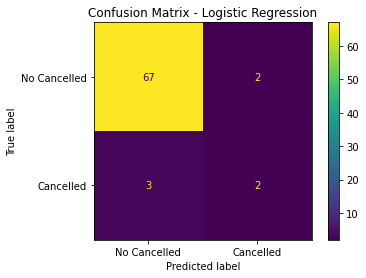

In [26]:
display_cm_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No Cancelled", "Cancelled"]
)

display_cm_logistic.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [27]:
precision_logistic = precision_score(y_test, y_pred_logistic, zero_division=0)
recall_logistic = recall_score(y_test, y_pred_logistic, zero_division=0)
f1_logistic = f1_score(y_test, y_pred_logistic, zero_division=0)
print("Precision:", precision_logistic)
print("Recall:", recall_logistic)
print("F1-score:", f1_logistic)

Precision: 0.5
Recall: 0.4
F1-score: 0.4444444444444445


In [28]:
print("Classification Report:")
print(classification_report(y_test, y_pred_logistic, target_names=["No Cancelled", "Cancelled"], zero_division=0))

Classification Report:
              precision    recall  f1-score   support

No Cancelled       0.96      0.97      0.96        69
   Cancelled       0.50      0.40      0.44         5

    accuracy                           0.93        74
   macro avg       0.73      0.69      0.70        74
weighted avg       0.93      0.93      0.93        74



In [29]:
#Build SVM
from sklearn.svm import SVC
svm_model = SVC(random_state=42, class_weight='balanced')
svm_model.fit(X_train_preprocessed, y_train)
print("SVM model trained successfully!")

SVM model trained successfully!


In [30]:
y_pred_svm = svm_model.predict(X_test_preprocessed)
print("SVM predictions completed successfully!")

print("\nFirst 10 SVM predictions:")
print(y_pred_svm[:10])

SVM predictions completed successfully!

First 10 SVM predictions:
[0 0 0 0 0 0 0 0 0 0]


In [31]:
svm_comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "SVM_Predicted": y_pred_svm
})

display(svm_comparison_df.head(10))

,Actual,SVM_Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [32]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(y_test, y_pred_svm)

recall_svm = recall_score(y_test, y_pred_svm)

f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Evaluation Metrics:")
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1-score:", f1_svm)

SVM Evaluation Metrics:
Accuracy: 0.918918918918919
Precision: 0.4
Recall: 0.4
F1-score: 0.4000000000000001


In [33]:
#Create the confusion matrix for the SVM model
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix - SVM:")
print(cm_svm)

Confusion Matrix - SVM:
[[66  3]
 [ 3  2]]


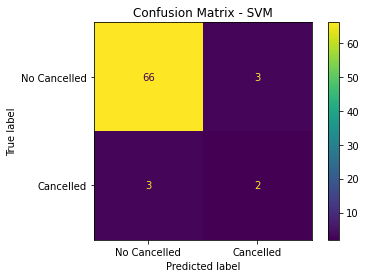

In [34]:
display_cm_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No Cancelled", "Cancelled"]
)

display_cm_svm.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

In [35]:
print("Classification Report - SVM:")
print(classification_report(y_test, y_pred_svm, target_names=["No Cancelled", "Cancelled"]))

Classification Report - SVM:
              precision    recall  f1-score   support

No Cancelled       0.96      0.96      0.96        69
   Cancelled       0.40      0.40      0.40         5

    accuracy                           0.92        74
   macro avg       0.68      0.68      0.68        74
weighted avg       0.92      0.92      0.92        74



In [36]:
#Compare both models
model_comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],
    "Accuracy": [accuracy_logistic, accuracy_svm],
    "Precision": [precision_logistic, precision_svm],
    "Recall": [recall_logistic, recall_svm],
    "F1-score": [f1_logistic, f1_svm]
})

display(model_comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.932432,0.5,0.4,0.444444
1,SVM,0.918919,0.4,0.4,0.400000


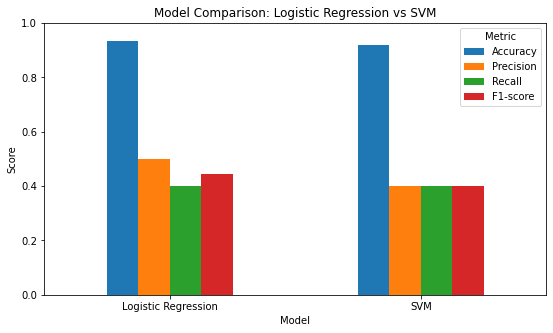

In [37]:
model_comparison_df.set_index("Model").plot(kind="bar", figsize=(9, 5))
plt.title("Model Comparison: Logistic Regression vs SVM")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

In [38]:
print("Model Evaluation Summary")
print("--"*50)
print('''
After comparing Logistic Regression and SVM on the hotel booking cancellation dataset, the Logistic Regression model generally performs better, achieving higher accuracy,
precision and f1-score for the cancellation class.

For this business problem, recall is the most important metric. The hotel's primary goal is to detect as many genuine cancellations as possible.
Failing to catch a real cancellation results in an empty room and direct revenue loss.

A false positive in this context means the model predicts a guest will cancel, but they actually keep their reservation and show up.
A false negative means the model misses a guest who does cancel, leaving the hotel no time to intervene. This is a more costly mistake: rooms are left empty, revenue is lost, and opportunities for action are missed.

One possible limitation is temporal or seasonal bias. If the dataset is collected over a specific period, such as summer or peak tourist season,
then the cancellation patterns it reflects may not represent typical year-round booking behavior.

Human judgment remains essential because while models learn from historical models, they cannot account for real-time context.
Human judgment remains essential because while models learn from historical models, they cannot account for real-time context.
''')

Model Evaluation Summary
----------------------------------------------------------------------------------------------------

After comparing Logistic Regression and SVM on the hotel booking cancellation dataset, the Logistic Regression model generally performs better, achieving higher accuracy,
precision and f1-score for the cancellation class.

For this business problem, recall is the most important metric. The hotel's primary goal is to detect as many genuine cancellations as possible.
Failing to catch a real cancellation results in an empty room and direct revenue loss.

A false positive in this context means the model predicts a guest will cancel, but they actually keep their reservation and show up.
A false negative means the model misses a guest who does cancel, leaving the hotel no time to intervene. This is a more costly mistake: rooms are left empty, revenue is lost, and opportunities for action are missed.

One possible limitation is temporal or seasonal bias. If the datase